In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
url = 'https://raw.githubusercontent.com/singhrau0/LTM_AIServices/refs/heads/main/Day%20-%209/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

print(f"Missing values in TotalCharges after imputation: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype after conversion: {df['TotalCharges'].dtype}")

Missing values in TotalCharges after imputation: 0
TotalCharges dtype after conversion: float64


/tmp/ipykernel_858/817956655.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [10]:
y = df['Churn']
X = df.drop(['Churn'], axis = 1)

In [11]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('customerID')
categorical_features.remove('Churn')

print(f"Updated Numeric Features: {numeric_features}")
print(f"Updated Categorical Features: {categorical_features}")

Updated Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Updated Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [13]:
numerical_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])

In [14]:
categorical_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Oencoder', OneHotEncoder(handle_unknown = 'ignore'))
])
y = LabelEncoder().fit_transform(y)

In [15]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [18]:
pipelines = {
    'LogisticRegression': Pipeline(steps = [('preprocess', preprocessor), ('classifier', LogisticRegression(max_iter=1000))]),
    'KNeighborsClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', KNeighborsClassifier())]),
    # 'MultinomialNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', MultinomialNB())]), # Note: MultinomialNB needs non-negative features. One-hot encoding produces this.
    # 'GaussianNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GaussianNB())]),
    'DecisionTreeClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', DecisionTreeClassifier())]),
    'SVC': Pipeline(steps = [('preprocess', preprocessor), ('classifier', SVC())]),
    'RandomForestClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', RandomForestClassifier())]),
    'GradientBoostingClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GradientBoostingClassifier())]),
    'AdaBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', AdaBoostClassifier())]),
    'XGBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])
}

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [20]:
fitted_models = {}
for name, pipeline in pipelines.items():
    print(f"Fitting {name}...")
    fitted_models[name] = pipeline.fit(X_train, y_train)
    print(f"{name} fitted.")

Fitting LogisticRegression...
LogisticRegression fitted.
Fitting KNeighborsClassifier...
KNeighborsClassifier fitted.
Fitting DecisionTreeClassifier...
DecisionTreeClassifier fitted.
Fitting SVC...
SVC fitted.
Fitting RandomForestClassifier...
RandomForestClassifier fitted.
Fitting GradientBoostingClassifier...
GradientBoostingClassifier fitted.
Fitting AdaBoostClassifier...
AdaBoostClassifier fitted.
Fitting XGBoostClassifier...
XGBoostClassifier fitted.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:21:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
results = {}
for name, model in fitted_models.items():
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1Score = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy:.4f}")
    print(f"Precision for {name}: {precision:.4f}")
    print(f"Recall for {name}: {recall:.4f}")
    print(f"F1 Score for {name}: {f1Score:.4f}")
    print(f"ROC AUC Score for {name}: {roc_auc:.4f}")
    print(f"Confusion Matrix for {name}:\n{cm}\n")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}\n")
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1Score': f1Score,
        'roc_auc': roc_auc,
        'y_pred': y_pred
    }

Evaluating LogisticRegression...
Accuracy for LogisticRegression: 0.8183
Precision for LogisticRegression: 0.6757
Recall for LogisticRegression: 0.6032
F1 Score for LogisticRegression: 0.6374
ROC AUC Score for LogisticRegression: 0.7495
Confusion Matrix for LogisticRegression:
[[928 108]
 [148 225]]

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409


Evaluating KNeighborsClassifier...
Accuracy for KNeighborsClassifier: 0.7771
Precision for KNeighborsClassifier: 0.5826
Recall for KNeighborsClassifier: 0.5576
F1 Score for KNeighborsClassifier: 0.5699
ROC AUC Score for KNeighborsClassifier: 0.7069
Confusion Matrix for KNeighborsClassifier:
[[887 149]
 [165 208]]

Classifi

In [22]:
model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
})
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.818311,0.675676,0.603217,0.637394
1,SVC,0.813343,0.693662,0.528150,0.599696
2,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046
3,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918
4,RandomForestClassifier,0.793471,0.650735,0.474531,0.548837
5,XGBoostClassifier,0.791341,0.632997,0.504021,0.561194
6,KNeighborsClassifier,0.777147,0.582633,0.557641,0.569863
7,DecisionTreeClassifier,0.715401,0.463731,0.479893,0.471673


In [23]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10]
}

dt_param_grid = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__penalty': ['l1', 'l2']
}

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

svc_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

gb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 1]
}

In [24]:
print("Starting GridSearchCV for RandomForestClassifier...")
rf_grid_search = GridSearchCV(pipelines['RandomForestClassifier'], rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train, y_train)

print(f"Best parameters for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_params_}")
print(f"Best accuracy for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_score_:.4f}")


rf_best_model_grid = rf_grid_search.best_estimator_

y_pred_rf_grid = rf_best_model_grid.predict(X_test)
accuracy_rf_grid = accuracy_score(y_test, y_pred_rf_grid)
precision_rf_grid = precision_score(y_test, y_pred_rf_grid)
recall_rf_grid = recall_score(y_test, y_pred_rf_grid)
f1Score_rf_grid = f1_score(y_test, y_pred_rf_grid)
roc_auc_rf_grid = roc_auc_score(y_test, y_pred_rf_grid)

results['RandomForest_GridSearchCV'] = {
    'accuracy': accuracy_rf_grid,
    'precision': precision_rf_grid,
    'recall': recall_rf_grid,
    'f1Score': f1Score_rf_grid,
    'roc_auc': roc_auc_rf_grid,
    'y_pred': y_pred_rf_grid
}

print(f"Accuracy for Tuned RandomForestClassifier (GridSearchCV): {accuracy_rf_grid:.4f}")

Starting GridSearchCV for RandomForestClassifier...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters for RandomForestClassifier (GridSearchCV): {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best accuracy for RandomForestClassifier (GridSearchCV): 0.8049
Accuracy for Tuned RandomForestClassifier (GridSearchCV): 0.8105


In [25]:
print("Starting GridSearchCV for DecisionTreeClassifier...")
dt_grid_search = GridSearchCV(pipelines['DecisionTreeClassifier'], dt_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
dt_grid_search.fit(X_train, y_train)

print(f"Best parameters for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_params_}")
print(f"Best accuracy for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_score_:.4f}")

dt_best_model_grid = dt_grid_search.best_estimator_

y_pred_dt_grid = dt_best_model_grid.predict(X_test)
accuracy_dt_grid = accuracy_score(y_test, y_pred_dt_grid)
precision_dt_grid = precision_score(y_test, y_pred_dt_grid)
recall_dt_grid = recall_score(y_test, y_pred_dt_grid)
f1Score_dt_grid = f1_score(y_test, y_pred_dt_grid)
roc_auc_dt_grid = roc_auc_score(y_test, y_pred_dt_grid)

results['DecisionTree_GridSearchCV'] = {
    'accuracy': accuracy_dt_grid,
    'precision': precision_dt_grid,
    'recall': recall_dt_grid,
    'f1Score': f1Score_dt_grid,
    'roc_auc': roc_auc_dt_grid,
    'y_pred': y_pred_dt_grid
}

print(f"Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): {accuracy_dt_grid:.4f}")

Starting GridSearchCV for DecisionTreeClassifier...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters for DecisionTreeClassifier (GridSearchCV): {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best accuracy for DecisionTreeClassifier (GridSearchCV): 0.7872
Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): 0.8006


In [26]:
print("Starting GridSearchCV for XGBoostClassifier...")
xgb_grid_search = GridSearchCV(pipelines['XGBoostClassifier'], xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_params_}")
print(f"Best accuracy for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_score_:.4f}")

xgb_best_model_grid = xgb_grid_search.best_estimator_

y_pred_xgb_grid = xgb_best_model_grid.predict(X_test)
accuracy_xgb_grid = accuracy_score(y_test, y_pred_xgb_grid)
precision_xgb_grid = precision_score(y_test, y_pred_xgb_grid)
recall_xgb_grid = recall_score(y_test, y_pred_xgb_grid)
f1Score_xgb_grid = f1_score(y_test, y_pred_xgb_grid)
roc_auc_xgb_grid = roc_auc_score(y_test, y_pred_xgb_grid)

results['XGBoost_GridSearchCV'] = {
    'accuracy': accuracy_xgb_grid,
    'precision': precision_xgb_grid,
    'recall': recall_xgb_grid,
    'f1Score': f1Score_xgb_grid,
    'roc_auc': roc_auc_xgb_grid,
    'y_pred': y_pred_xgb_grid
}

print(f"Accuracy for Tuned XGBoostClassifier (GridSearchCV): {accuracy_xgb_grid:.4f}")

Starting GridSearchCV for XGBoostClassifier...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters for XGBoostClassifier (GridSearchCV): {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best accuracy for XGBoostClassifier (GridSearchCV): 0.8044
Accuracy for Tuned XGBoostClassifier (GridSearchCV): 0.8112


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:30:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
hyperparameters = {}

for name, moedl in pipelines.items():
  parameters = model.get_params()
  hyperparameters[name] = parameters

In [28]:
print("Starting GridSearchCV for LogisticRegression...")
lr_grid_search = GridSearchCV(pipelines['LogisticRegression'], lr_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid_search.fit(X_train, y_train)

print(f"Best parameters for LogisticRegression (GridSearchCV): {lr_grid_search.best_params_}")
print(f"Best accuracy for LogisticRegression (GridSearchCV): {lr_grid_search.best_score_:.4f}")

lr_best_model_grid = lr_grid_search.best_estimator_

y_pred_lr_grid = lr_best_model_grid.predict(X_test)
accuracy_lr_grid = accuracy_score(y_test, y_pred_lr_grid)
precision_lr_grid = precision_score(y_test, y_pred_lr_grid)
recall_lr_grid = recall_score(y_test, y_pred_lr_grid)
f1Score_lr_grid = f1_score(y_test, y_pred_lr_grid)
roc_auc_lr_grid = roc_auc_score(y_test, y_pred_lr_grid)

results['LogisticRegression_GridSearchCV'] = {
    'accuracy': accuracy_lr_grid,
    'precision': precision_lr_grid,
    'recall': recall_lr_grid,
    'f1Score': f1Score_lr_grid,
    'roc_auc': roc_auc_lr_grid,
    'y_pred': y_pred_lr_grid
}

print(f"Accuracy for Tuned LogisticRegression (GridSearchCV): {accuracy_lr_grid:.4f}")

Starting GridSearchCV for LogisticRegression...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for LogisticRegression (GridSearchCV): {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best accuracy for LogisticRegression (GridSearchCV): 0.8010
Accuracy for Tuned LogisticRegression (GridSearchCV): 0.8190


In [29]:
print("Starting GridSearchCV for KNeighborsClassifier...")
knn_grid_search = GridSearchCV(pipelines['KNeighborsClassifier'], knn_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid_search.fit(X_train, y_train)

print(f"Best parameters for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_params_}")
print(f"Best accuracy for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_score_:.4f}")

knn_best_model_grid = knn_grid_search.best_estimator_

y_pred_knn_grid = knn_best_model_grid.predict(X_test)
accuracy_knn_grid = accuracy_score(y_test, y_pred_knn_grid)
precision_knn_grid = precision_score(y_test, y_pred_knn_grid)
recall_knn_grid = recall_score(y_test, y_pred_knn_grid)
f1Score_knn_grid = f1_score(y_test, y_pred_knn_grid)
roc_auc_knn_grid = roc_auc_score(y_test, y_pred_knn_grid)

results['KNeighborsClassifier_GridSearchCV'] = {
    'accuracy': accuracy_knn_grid,
    'precision': precision_knn_grid,
    'recall': recall_knn_grid,
    'f1Score': f1Score_knn_grid,
    'roc_auc': roc_auc_knn_grid,
    'y_pred': y_pred_knn_grid
}

print(f"Accuracy for Tuned KNeighborsClassifier (GridSearchCV): {accuracy_knn_grid:.4f}")

Starting GridSearchCV for KNeighborsClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters for KNeighborsClassifier (GridSearchCV): {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Best accuracy for KNeighborsClassifier (GridSearchCV): 0.7794
Accuracy for Tuned KNeighborsClassifier (GridSearchCV): 0.7892


In [30]:
print("Starting GridSearchCV for SVC...")
svc_grid_search = GridSearchCV(pipelines['SVC'], svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid_search.fit(X_train, y_train)

print(f"Best parameters for SVC (GridSearchCV): {svc_grid_search.best_params_}")
print(f"Best accuracy for SVC (GridSearchCV): {svc_grid_search.best_score_:.4f}")

svc_best_model_grid = svc_grid_search.best_estimator_

y_pred_svc_grid = svc_best_model_grid.predict(X_test)
accuracy_svc_grid = accuracy_score(y_test, y_pred_svc_grid)
precision_svc_grid = precision_score(y_test, y_pred_svc_grid)
recall_svc_grid = recall_score(y_test, y_pred_svc_grid)
f1Score_svc_grid = f1_score(y_test, y_pred_svc_grid)
roc_auc_svc_grid = roc_auc_score(y_test, y_pred_svc_grid)

results['SVC_GridSearchCV'] = {
    'accuracy': accuracy_svc_grid,
    'precision': precision_svc_grid,
    'recall': recall_svc_grid,
    'f1Score': f1Score_svc_grid,
    'roc_auc': roc_auc_svc_grid,
    'y_pred': y_pred_svc_grid
}

print(f"Accuracy for Tuned SVC (GridSearchCV): {accuracy_svc_grid:.4f}")

Starting GridSearchCV for SVC...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for SVC (GridSearchCV): {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best accuracy for SVC (GridSearchCV): 0.8000
Accuracy for Tuned SVC (GridSearchCV): 0.8133


In [31]:
print("Starting GridSearchCV for GradientBoostingClassifier...")
gb_grid_search = GridSearchCV(pipelines['GradientBoostingClassifier'], gb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
gb_grid_search.fit(X_train, y_train)

print(f"Best parameters for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_params_}")
print(f"Best accuracy for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_score_:.4f}")

gb_best_model_grid = gb_grid_search.best_estimator_

y_pred_gb_grid = gb_best_model_grid.predict(X_test)
accuracy_gb_grid = accuracy_score(y_test, y_pred_gb_grid)
precision_gb_grid = precision_score(y_test, y_pred_gb_grid)
recall_gb_grid = recall_score(y_test, y_pred_gb_grid)
f1Score_gb_grid = f1_score(y_test, y_pred_gb_grid)
roc_auc_gb_grid = roc_auc_score(y_test, y_pred_gb_grid)

results['GradientBoostingClassifier_GridSearchCV'] = {
    'accuracy': accuracy_gb_grid,
    'precision': precision_gb_grid,
    'recall': recall_gb_grid,
    'f1Score': f1Score_gb_grid,
    'roc_auc': roc_auc_gb_grid,
    'y_pred': y_pred_gb_grid
}

print(f"Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): {accuracy_gb_grid:.4f}")

Starting GridSearchCV for GradientBoostingClassifier...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for GradientBoostingClassifier (GridSearchCV): {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best accuracy for GradientBoostingClassifier (GridSearchCV): 0.8012
Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): 0.8105


In [32]:
print("Starting GridSearchCV for AdaBoostClassifier...")
ada_grid_search = GridSearchCV(pipelines['AdaBoostClassifier'], ada_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
ada_grid_search.fit(X_train, y_train)

print(f"Best parameters for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_params_}")
print(f"Best accuracy for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_score_:.4f}")

ada_best_model_grid = ada_grid_search.best_estimator_

y_pred_ada_grid = ada_best_model_grid.predict(X_test)
accuracy_ada_grid = accuracy_score(y_test, y_pred_ada_grid)
precision_ada_grid = precision_score(y_test, y_pred_ada_grid)
recall_ada_grid = recall_score(y_test, y_pred_ada_grid)
f1Score_ada_grid = f1_score(y_test, y_pred_ada_grid)
roc_auc_ada_grid = roc_auc_score(y_test, y_pred_ada_grid)

results['AdaBoostClassifier_GridSearchCV'] = {
    'accuracy': accuracy_ada_grid,
    'precision': precision_ada_grid,
    'recall': recall_ada_grid,
    'f1Score': f1Score_ada_grid,
    'roc_auc': roc_auc_ada_grid,
    'y_pred': y_pred_ada_grid
}

print(f"Accuracy for Tuned AdaBoostClassifier (GridSearchCV): {accuracy_ada_grid:.4f}")

Starting GridSearchCV for AdaBoostClassifier...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters for AdaBoostClassifier (GridSearchCV): {'classifier__learning_rate': 1, 'classifier__n_estimators': 100}
Best accuracy for AdaBoostClassifier (GridSearchCV): 0.7996
Accuracy for Tuned AdaBoostClassifier (GridSearchCV): 0.8105


In [33]:
final_model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
    'ROC AUC Score': [metrics['roc_auc'] for metrics in results.values()]
})
final_model_comparison = final_model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,LogisticRegression_GridSearchCV,0.819021,0.678788,0.600536,0.637269,0.749110
1,LogisticRegression,0.818311,0.675676,0.603217,0.637394,0.749485
2,SVC_GridSearchCV,0.813343,0.693662,0.528150,0.599696,0.722087
3,SVC,0.813343,0.693662,0.528150,0.599696,0.722087
4,XGBoost_GridSearchCV,0.811214,0.678930,0.544236,0.604167,0.725786
5,RandomForest_GridSearchCV,0.810504,0.681507,0.533512,0.598496,0.721872
6,GradientBoostingClassifier_GridSearchCV,0.810504,0.686620,0.522788,0.593607,0.718440
7,AdaBoostClassifier_GridSearchCV,0.810504,0.662577,0.579088,0.618026,0.736455
8,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046,0.735115
9,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918,0.719941


In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Applying preprocessor to X_train and X_test...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Shape of preprocessed X_train: {X_train_preprocessed.shape}")
print(f"Shape of preprocessed X_test: {X_test_preprocessed.shape}")

Applying preprocessor to X_train and X_test...
Shape of preprocessed X_train: (5634, 44)
Shape of preprocessed X_test: (1409, 44)


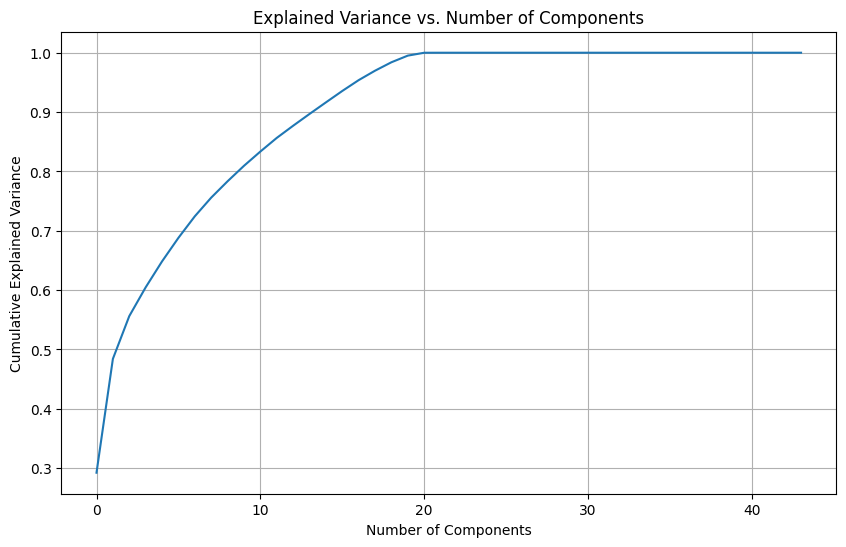

Number of components to explain 95% variance: 17
Shape of X_train after PCA: (5634, 17)
Shape of X_test after PCA: (1409, 17)


In [35]:
pca = PCA()
pca.fit(X_train_preprocessed)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

explained_variance_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {explained_variance_95}")

pca_final = PCA(n_components=explained_variance_95)
X_train_pca = pca_final.fit_transform(X_train_preprocessed)
X_test_pca = pca_final.transform(X_test_preprocessed)

print(f"Shape of X_train after PCA: {X_train_pca.shape}")
print(f"Shape of X_test after PCA: {X_test_pca.shape}")

In [36]:
print("\nEigenvalues (Explained Variance):")
display(pd.DataFrame({'Eigenvalue': pca.explained_variance_}).T)

print("\nEigenvectors (Principal Components):\n(Each row is a principal component, ordered by explained variance)")
display(pd.DataFrame(pca.components_))


Eigenvalues (Explained Variance):


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
Eigenvalue,3.350327,2.199929,0.825955,0.555672,0.501524,0.454982,0.416136,0.36053,0.316201,0.298545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Eigenvectors (Principal Components):
(Each row is a principal component, ordered by explained variance)


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,3.237996e-01,4.914976e-01,4.755852e-01,0.003887,-0.003887,-0.071070,0.071070,0.005275,-0.005275,-0.008918,...,0.169664,-0.054382,0.020474,0.033908,-0.091322,0.091322,0.031306,0.028286,0.038020,-0.097612
1,4.779465e-01,-1.915566e-01,2.825437e-01,0.000377,-0.000377,-0.133806,0.133806,-0.105506,0.105506,-0.016302,...,0.005495,-0.246768,0.065903,0.180865,0.097357,-0.097357,0.051225,0.061853,-0.139487,0.026409
2,1.406241e-01,-2.781447e-01,-3.115767e-02,-0.016557,0.016557,-0.078969,0.078969,-0.109096,0.109096,0.189592,...,-0.106798,-0.099986,0.039650,0.060335,0.119233,-0.119233,0.038341,0.054633,-0.120343,0.027369
3,9.718706e-02,-5.472287e-02,9.125060e-02,0.013717,-0.013717,0.494363,-0.494363,0.434132,-0.434132,0.065470,...,0.060950,-0.064249,0.038524,0.025726,0.042509,-0.042509,0.018293,0.016021,-0.060032,0.025718
4,-5.331151e-02,2.273108e-02,-2.165667e-02,0.700567,-0.700567,-0.019089,0.019089,-0.016652,0.016652,-0.005762,...,0.009524,0.002616,-0.006198,0.003582,-0.008326,0.008326,0.007237,-0.000793,-0.022810,0.016366
5,3.608492e-01,-1.671722e-01,1.170870e-01,0.060871,-0.060871,0.029054,-0.029054,0.139955,-0.139955,-0.041510,...,-0.316765,0.040658,-0.062448,0.021790,-0.124796,0.124796,0.049905,0.025587,0.018282,-0.093773
6,-7.574539e-02,2.338100e-01,8.697172e-02,-0.018249,0.018249,0.045228,-0.045228,0.006288,-0.006288,-0.231372,...,-0.144848,-0.015367,0.022130,-0.006763,0.482138,-0.482138,0.021154,-0.002048,-0.110967,0.091861
7,4.176638e-02,-5.664537e-02,-4.853904e-02,0.054082,-0.054082,-0.048854,0.048854,0.041765,-0.041765,0.141158,...,0.123952,0.031627,-0.055188,0.023561,0.441275,-0.441275,-0.010726,-0.033978,0.118770,-0.074066
8,2.080972e-01,-3.452630e-02,4.808880e-02,0.027455,-0.027455,-0.001903,0.001903,0.045570,-0.045570,-0.070403,...,-0.025727,-0.114951,0.049615,0.065337,-0.066547,0.066547,0.066309,0.059076,-0.057180,-0.068205
9,-2.376060e-01,9.245847e-02,-8.115938e-02,-0.016055,0.016055,0.063167,-0.063167,-0.087124,0.087124,-0.048460,...,-0.053599,0.072048,-0.145104,0.073056,-0.096275,0.096275,-0.016966,0.015924,-0.118317,0.119360


In [37]:
print("\nCovariance Matrix of the preprocessed training data:")
display(pd.DataFrame(pca.get_covariance()))


Covariance Matrix of the preprocessed training data:


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,1.000178,0.253848,0.826584,-0.000341,0.000341,-0.189425,0.189425,-0.074268,0.074268,-0.001933,...,0.141965,-0.318818,0.083512,0.235307,-0.004016,0.004016,0.093545,0.098031,-0.094664,-0.096912
1,0.253848,1.000178,0.652892,0.009142,-0.009142,-0.052889,0.052889,0.051648,-0.051648,-0.074283,...,0.306397,0.028910,0.001356,-0.030267,-0.175238,0.175238,0.021629,0.010568,0.126559,-0.158757
2,0.826584,0.652892,1.000178,0.003130,-0.003130,-0.161124,0.161124,-0.030327,0.030327,-0.034031,...,0.254610,-0.221190,0.069792,0.151398,-0.080232,0.080232,0.074599,0.074856,-0.026404,-0.123051
3,-0.000341,0.009142,0.003130,0.249890,-0.249890,-0.001761,0.001761,0.002235,-0.002235,-0.001623,...,0.002272,0.000498,-0.002120,0.001622,-0.003872,0.003872,0.002376,0.000132,-0.001785,-0.000723
4,0.000341,-0.009142,-0.003130,-0.249890,0.249890,0.001761,-0.001761,-0.002235,0.002235,0.001623,...,-0.002272,-0.000498,0.002120,-0.001622,0.003872,-0.003872,-0.002376,-0.000132,0.001785,0.000723
5,-0.189425,-0.052889,-0.161124,-0.001761,0.001761,0.249806,-0.249806,0.103051,-0.103051,0.004345,...,-0.028125,0.070281,-0.017525,-0.052756,-0.004111,0.004111,-0.019904,-0.020495,0.020124,0.020274
6,0.189425,0.052889,0.161124,0.001761,-0.001761,-0.249806,0.249806,-0.103051,0.103051,-0.004345,...,0.028125,-0.070281,0.017525,0.052756,0.004111,-0.004111,0.019904,0.020495,-0.020124,-0.020274
7,-0.074268,0.051648,-0.030327,0.002235,-0.002235,0.103051,-0.103051,0.209524,-0.209524,0.000336,...,0.007508,0.052363,-0.012240,-0.040123,-0.023833,0.023833,-0.006956,-0.014818,0.033142,-0.011368
8,0.074268,-0.051648,0.030327,-0.002235,0.002235,-0.103051,0.103051,-0.209524,0.209524,-0.000336,...,-0.007508,-0.052363,0.012240,0.040123,0.023833,-0.023833,0.006956,0.014818,-0.033142,0.011368
9,-0.001933,-0.074283,-0.034031,-0.001623,0.001623,0.004345,-0.004345,0.000336,-0.000336,0.088393,...,0.004215,-0.000366,0.001110,-0.000744,0.002622,-0.002622,-0.000762,0.001914,-0.000334,-0.000818
